In [2]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.auto import tqdm
from google.oauth2 import service_account
import numpy as np

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = '../google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'gdelt-analysis-494301'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [3]:
# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    EventCode,
    GoldsteinScale, 
    NumMentions, 
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401 
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
  AND IsRootEvent = 1                 -- 핵심 사건만 필터링
  AND ActionGeo_Type IN (3, 4, 5)
"""

# 2. 데이터 불러오기
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("데이터 불러오기 완료")
display(df.head())

Downloading: 100%|██████████|
데이터 불러오기 완료


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20160522,150,-7.2,5,-0.806452,4,39.9289,116.388,http://bilbaoya.com/2016/05/23/taiwan-swears-i...
1,20160522,150,-7.2,5,0.634249,4,25.0327,121.275,http://fait-religieux.com/2016/05/22/taiwan-sw...
2,20160624,190,-10.0,10,-2.474227,4,39.9289,116.388,http://lucenainformacion.com/2016/06/24/putin-...
3,20160923,151,-7.2,5,-4.106280,4,15.0000,115.000,http://www.morningnewsusa.com/south-china-sea-...
4,20160923,190,-10.0,10,-4.777595,5,26.5450,117.843,http://nation.com.pk/international/23-Sep-2016...


In [3]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')

In [4]:
# 1. 전체 날짜 범위 생성
all_dates = pd.date_range(start=df['SQLDATE'].min(), end=df['SQLDATE'].max())

# 2. 사건 개수가 아닌 '기사 언급량(NumMentions)'의 합계로 계산
ts_data = df.groupby('SQLDATE')['NumMentions'].sum().reindex(all_dates, fill_value=0).to_frame(name='event_count')

# 3. 기초 통계량 재계산
avg_events = ts_data['event_count'].mean()
median_events = ts_data['event_count'].median()
std_events = ts_data['event_count'].std()

print(f"평균 일일 기사 언급량: {avg_events:.2f}")
print(f"중위수 일일 기사 언급량: {median_events:.2f}")
print(f"표준편차: {std_events:.2f}")

평균 일일 기사 언급량: 33.05
중위수 일일 기사 언급량: 1.00
표준편차: 158.17


In [5]:
# 1. 전체 날짜 범위 생성
all_dates = pd.date_range(start=df['SQLDATE'].min(), end=df['SQLDATE'].max())

# 2. 사건 개수가 아닌 '기사 언급량(NumMentions)'의 합계로 계산
ts_data = df.groupby('SQLDATE')['NumMentions'].sum().reindex(all_dates, fill_value=0).to_frame(name='event_count')

# 3. 기초 통계량 재계산
avg_events = ts_data['event_count'].mean()
median_events = ts_data['event_count'].median()
std_events = ts_data['event_count'].std()

# 제대로 합산되었는지 검증하기 위한 최대값 확인
max_events = ts_data['event_count'].max()

print(f"최대 일일 기사 언급량: {max_events:.0f} (4595가 나오면 성공!)")
print(f"평균 일일 기사 언급량: {avg_events:.2f}")
print(f"중위수 일일 기사 언급량: {median_events:.2f}")
print(f"표준편차: {std_events:.2f}")

최대 일일 기사 언급량: 4595 (4595가 나오면 성공!)
평균 일일 기사 언급량: 33.05
중위수 일일 기사 언급량: 1.00
표준편차: 158.17


--- 분석 기준: 기사 언급량 합계 (NumMentions Sum) ---
--- 전체 평균 기사량: 33.05 ---


,event_count,MA30,ratio_ma30
2022-08-04,4595,330.933333,13.884972
2016-05-20,2729,100.600000,27.127237
2016-08-01,2480,101.766667,24.369473
2025-02-27,2197,89.033333,24.676151
2023-06-09,2055,107.733333,19.074876
2022-08-03,1988,177.766667,11.183199
2021-10-03,1775,149.933333,11.838595
2015-11-07,1738,66.300000,26.214178
2022-07-30,1642,78.466667,20.926083
2023-04-09,1585,174.033333,9.107451


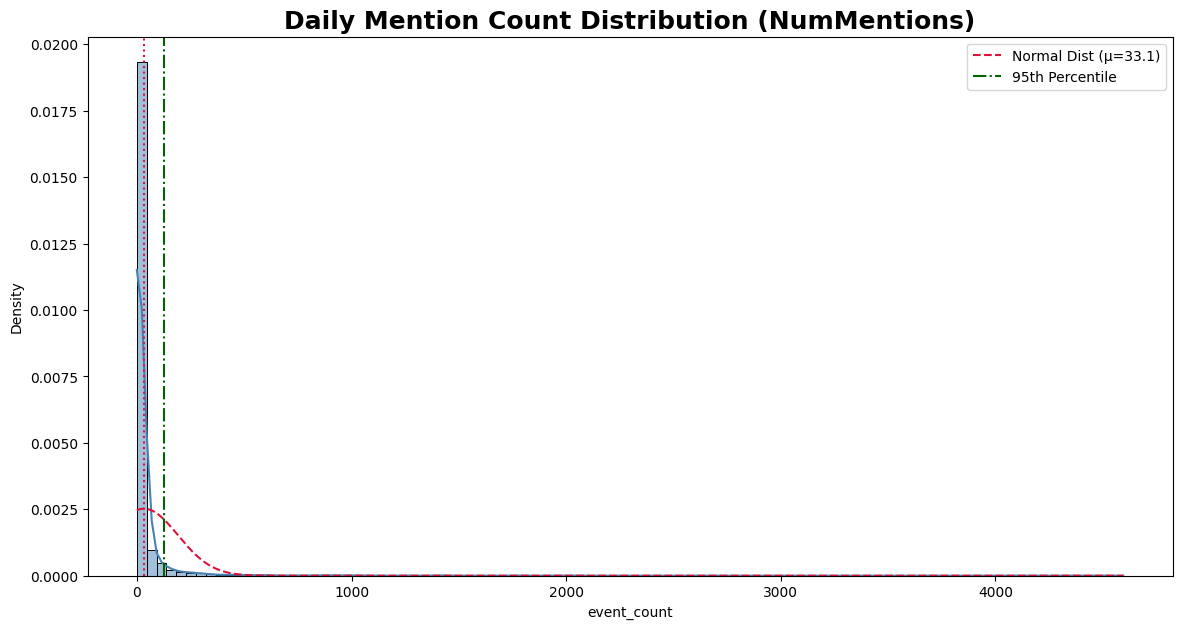

In [6]:
import numpy as np
import scipy.stats as stats

# 이동평균 및 증가율 계산
ts_data['MA14'] = ts_data['event_count'].rolling(window=14).mean()
ts_data['MA30'] = ts_data['event_count'].rolling(window=30).mean()
ts_data['ratio_ma30'] = ts_data['event_count'] / ts_data['MA30'].replace(0, np.nan)

# 임계치 및 급증일 추출
avg_events = ts_data['event_count'].mean()
threshold_95 = ts_data['ratio_ma30'].quantile(0.95)

anomalies = ts_data[
    (ts_data['event_count'] >= avg_events) & 
    (ts_data['ratio_ma30'] >= threshold_95)
].copy()

# 정렬 및 출력
top_spikes = anomalies.sort_values(by='event_count', ascending=False)
print(f"--- 분석 기준: 기사 언급량 합계 (NumMentions Sum) ---")
print(f"--- 전체 평균 기사량: {avg_events:.2f} ---")
display(top_spikes[['event_count', 'MA30', 'ratio_ma30']].head(10))

# 시각화 (기사량 분포)
plt.figure(figsize=(14, 7))
sns.histplot(ts_data['event_count'], kde=True, color='steelblue', stat="density", bins=100) # bins를 좀 더 세밀하게 조정

mu, std = ts_data['event_count'].mean(), ts_data['event_count'].std()
x = np.linspace(ts_data['event_count'].min(), ts_data['event_count'].max(), 500)
plt.plot(x, stats.norm.pdf(x, mu, std), color='crimson', linestyle='--', label=f'Normal Dist (μ={mu:.1f})')

plt.axvline(mu, color='crimson', linestyle=':')
plt.axvline(ts_data['event_count'].quantile(0.95), color='darkgreen', linestyle='-.', label='95th Percentile')

plt.title('Daily Mention Count Distribution (NumMentions)', fontsize=18, fontweight='bold')
plt.legend()
plt.show()

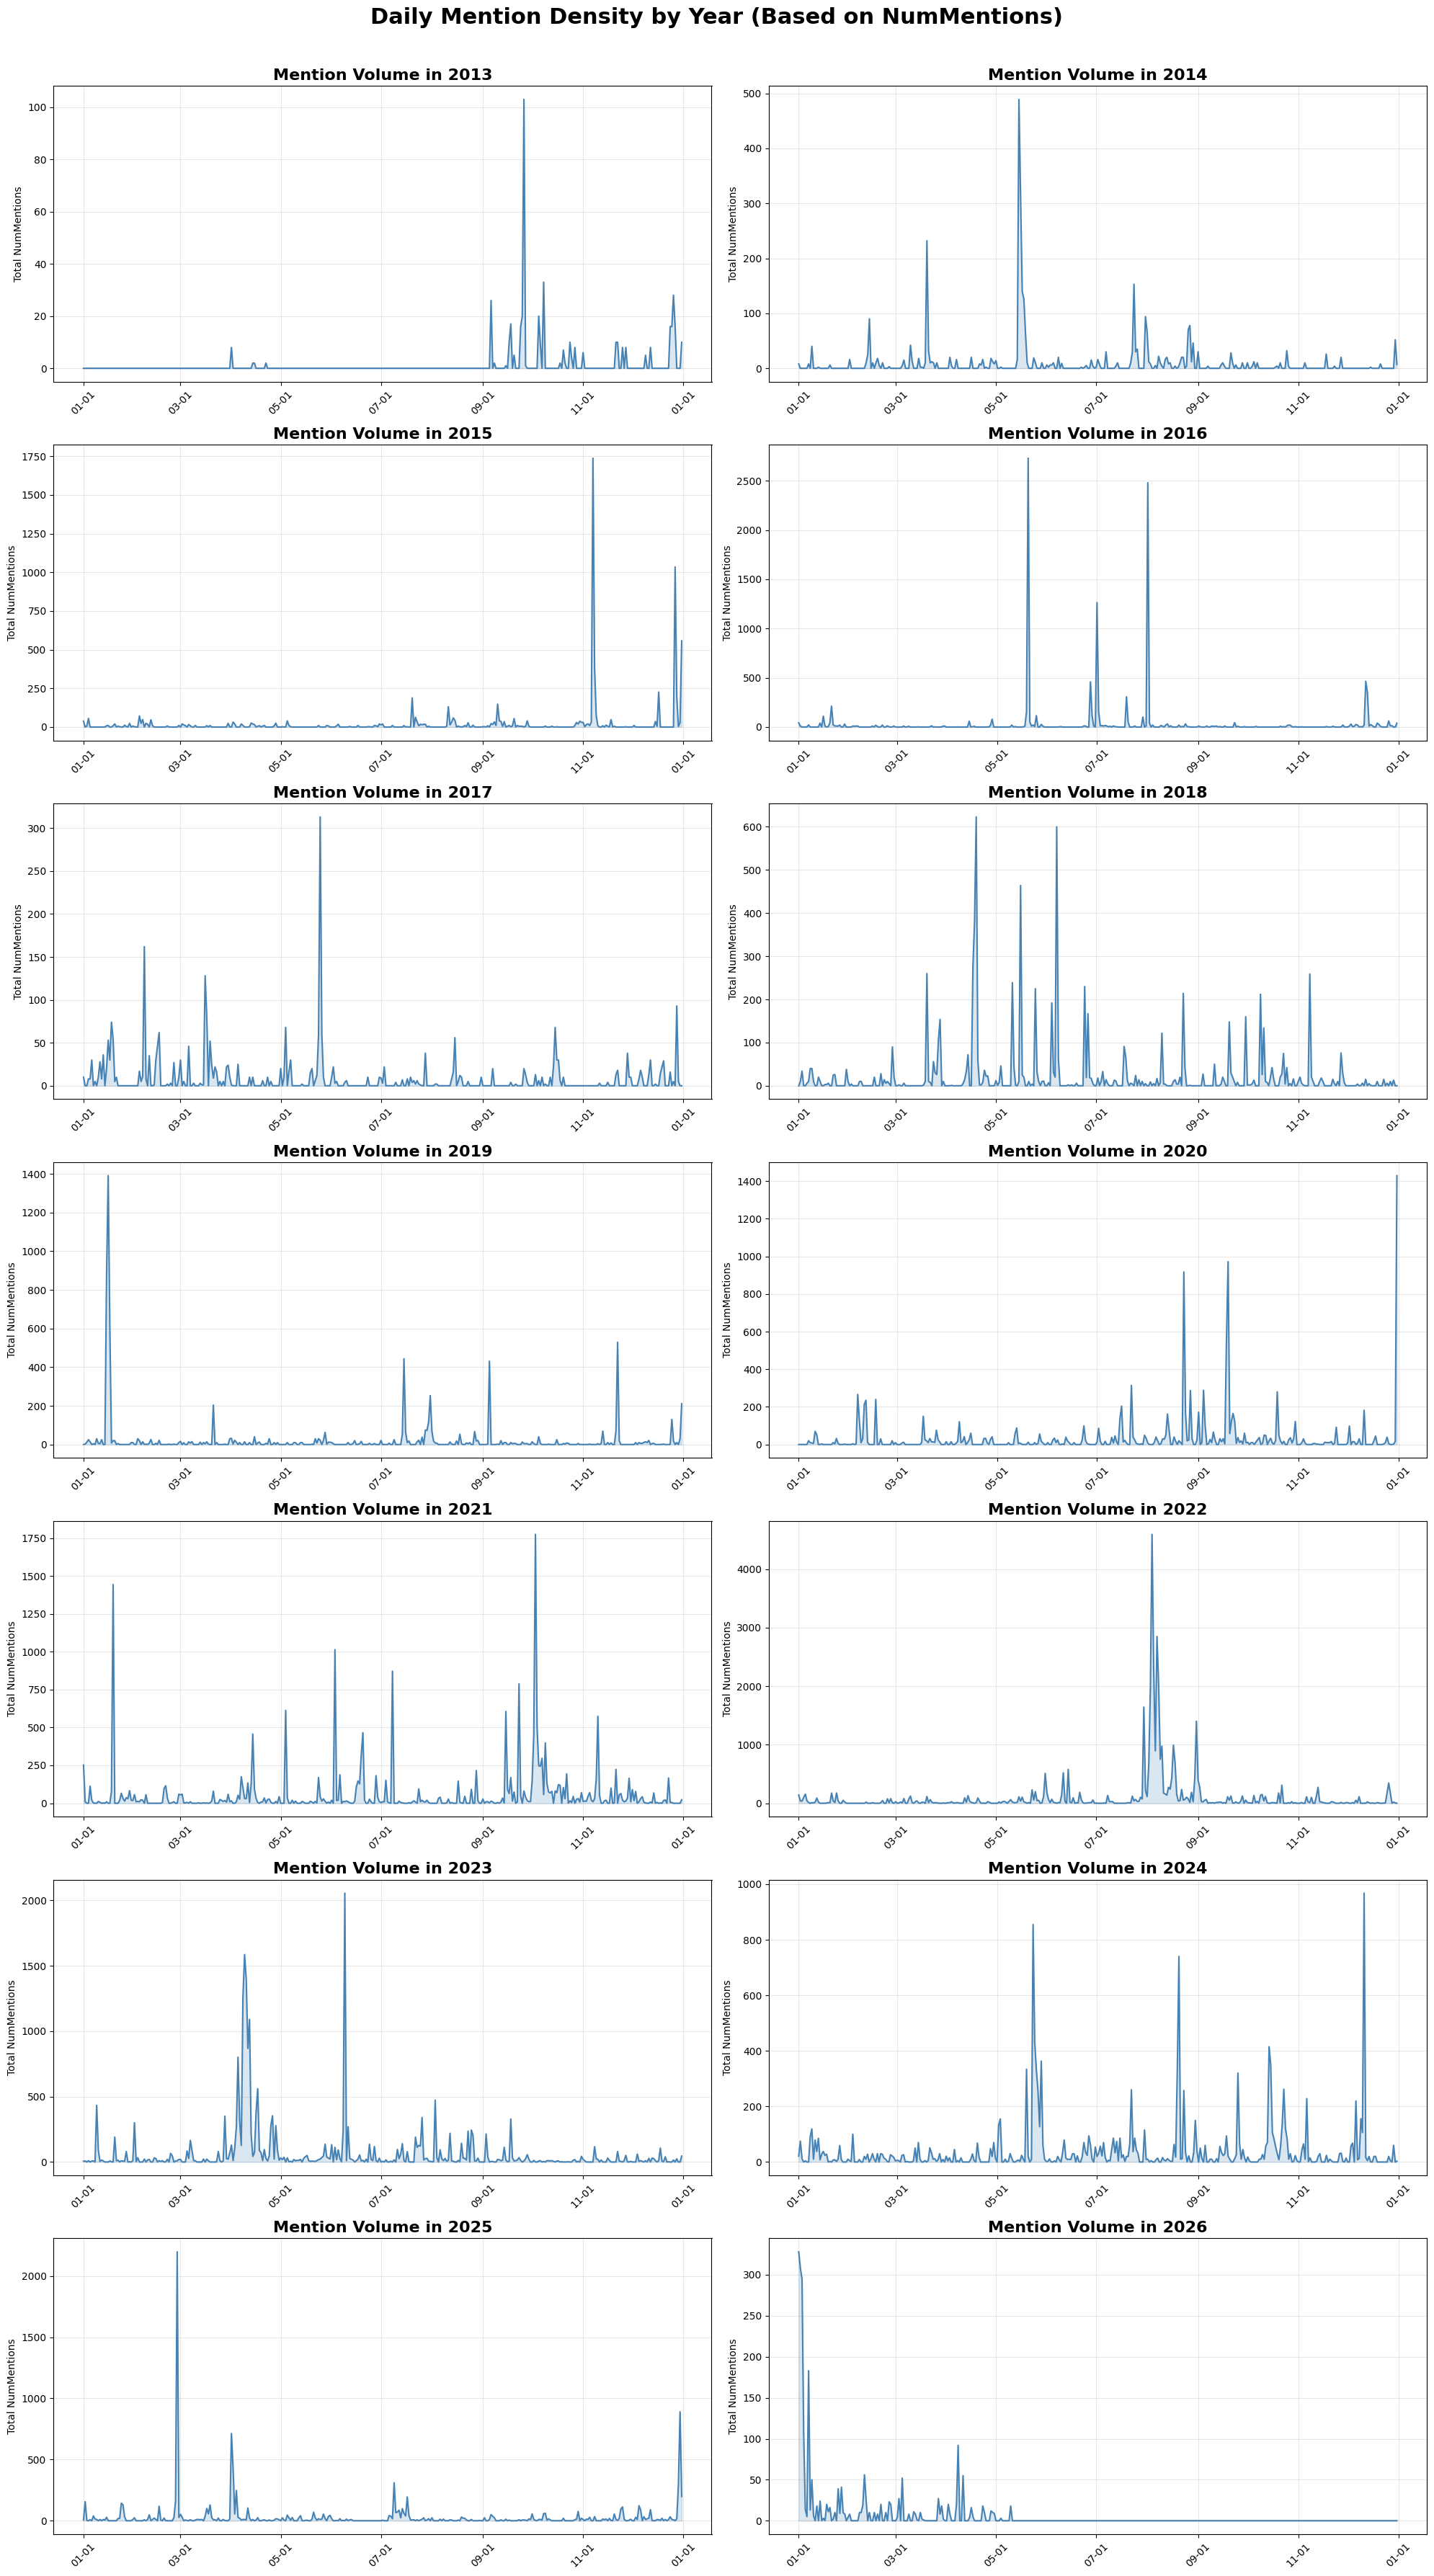

In [7]:
import math

# 연도 리스트 추출
years = sorted(df['SQLDATE'].dt.year.unique())
cols = 2
rows = math.ceil(len(years) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5), sharey=False) # sharey=False로 변경 권장
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    
    # 해당 연도의 데이터 필터링
    yearly_data = df[df['SQLDATE'].dt.year == year]
    
    # ---------------------------------------------------------
    # 수정 포인트: .size() 대신 ['NumMentions'].sum() 사용
    # ---------------------------------------------------------
    daily_counts = yearly_data.groupby('SQLDATE')['NumMentions'].sum()
    
    # 해당 연도의 전체 날짜 범위 생성
    full_range = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31')
    
    # 누락된 날짜 0으로 채우기
    daily_counts = daily_counts.reindex(full_range, fill_value=0)
    
    # 그래프 그리기
    ax.plot(daily_counts.index, daily_counts.values, color='steelblue', linewidth=1.5)
    ax.fill_between(daily_counts.index, daily_counts.values, color='steelblue', alpha=0.2)
    
    # 시각화 디테일
    ax.set_title(f'Mention Volume in {year}', fontsize=16, fontweight='bold')
    ax.set_ylabel('Total NumMentions') # Y축 라벨 수정
    ax.grid(True, alpha=0.3)
    
    # X축 날짜 포맷 개선 (연도 제외 월/일만 표시하여 가독성 업)
    import matplotlib.dates as mdates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.tick_params(axis='x', rotation=45)

# 남는 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Daily Mention Density by Year (Based on NumMentions)', fontsize=22, y=1.02, fontweight='bold')
plt.show()

In [8]:
# 결측치 없는 이동평균선 계산
# min_periods=1을 넣어 분석 기간 첫날부터 단 하루도 누락 없이 계산
ts_data['MA7'] = ts_data['event_count'].rolling(window=7, min_periods=1).mean()
ts_data['MA14'] = ts_data['event_count'].rolling(window=14, min_periods=1).mean()
ts_data['MA30'] = ts_data['event_count'].rolling(window=30, min_periods=1).mean()

# 이동평균선 상회(Spike) 일수 계산
# 조건 1: 오늘 기사량이 이동평균선보다 클 것
# 조건 2: 오늘 기사량이 0건은 아닐 것 (첫 번째 코드의 안전장치)
over_ma7 = ts_data[(ts_data['event_count'] > ts_data['MA7']) & (ts_data['event_count'] > 0)]
over_ma14 = ts_data[(ts_data['event_count'] > ts_data['MA14']) & (ts_data['event_count'] > 0)]
over_ma30 = ts_data[(ts_data['event_count'] > ts_data['MA30']) & (ts_data['event_count'] > 0)]
strong_spikes = ts_data[(ts_data['event_count'] > ts_data['MA7']) & (ts_data['event_count'] > ts_data['MA14']) & (ts_data['event_count'] > ts_data['MA30']) & (ts_data['event_count'] > 0)]

count_ma7 = len(over_ma7)
count_ma14 = len(over_ma14)
count_ma30 = len(over_ma30)
count_strong = len(strong_spikes)
total_days = len(ts_data)


# 결과를 DataFrame으로 보기 좋게 정리
summary_df = pd.DataFrame({
    '기준선 (Baseline)': [
        '7일 이동평균 상회 (단기 스파이크)',
        '14일 이동평균 상회 (단기 스파이크)', 
        '30일 이동평균 상회 (장기 스파이크)', 
        '7,14,30일 동시 상회 (강한 스파이크)'
    ],
    '돌파 일수 (Days)': [
        count_ma7,
        count_ma14, 
        count_ma30, 
        count_strong
    ],
    '전체 대비 비율 (%)': [
        round((count_ma7 / total_days) * 100, 2),
        round((count_ma14 / total_days) * 100, 2),
        round((count_ma30 / total_days) * 100, 2),
        round((count_strong / total_days) * 100, 2)
    ]
})

# 인덱스를 1부터 시작하도록 깔끔하게 정리 (선택 사항)
summary_df.index = summary_df.index + 1

# 최종 출력
print(f"--- 이동평균선 상회(Spike) 분석 결과 (총 분석 기간: {total_days}일) ---")
display(summary_df)

--- 이동평균선 상회(Spike) 분석 결과 (총 분석 기간: 4788일) ---


,기준선 (Baseline),돌파 일수 (Days),전체 대비 비율 (%)
1,7일 이동평균 상회 (단기 스파이크),1331,27.80
2,14일 이동평균 상회 (단기 스파이크),1213,25.33
3,30일 이동평균 상회 (장기 스파이크),1082,22.60
4,"7,14,30일 동시 상회 (강한 스파이크)",868,18.13


In [9]:
# 1. '7, 14, 30일 동시 상회' 날짜들만 추출하여 상위 30개 출력 (기사량 많은 순)
# strong_spikes는 앞선 코드에서 이미 정의됨
strong_spikes_list = strong_spikes.sort_values(by='event_count', ascending=False)

print(f"--- 7, 14, 30일 동시 상회 주요 날짜 (총 {len(strong_spikes_list)}일 중 상위 20일) ---")

# 인덱스(날짜)를 포함하여 주요 컬럼 출력
# 기사량(event_count)과 각 이동평균선 값을 함께 보여주면 비교가 쉽습니다.
display(strong_spikes_list[['event_count', 'MA7', 'MA14', 'MA30']].head(20))

--- 7, 14, 30일 동시 상회 주요 날짜 (총 868일 중 상위 20일) ---


,event_count,MA7,MA14,MA30
2022-08-04,4595,1327.571429,692.000000,330.933333
2022-08-07,2849,1912.428571,1110.785714,527.233333
2016-05-20,2729,413.714286,208.642857,100.600000
2016-08-01,2480,370.571429,211.571429,101.766667
2022-08-05,2283,1643.142857,854.785714,406.866667
2025-02-27,2197,340.428571,181.357143,89.033333
2023-06-09,2055,363.714286,210.785714,107.733333
2022-08-03,1988,685.714286,364.428571,177.766667
2021-10-03,1775,352.428571,247.785714,149.933333
2015-11-07,1738,264.000000,141.142857,66.300000


In [10]:
# 1. strong_spikes(7,14,30일 동시 상회) 중 event_count가 127건 이상인 날 필터링
refined_spikes = strong_spikes[strong_spikes['event_count'] >= 127].sort_values(by='event_count', ascending=False)

# 2. 결과 계산
final_count = len(refined_spikes)
total_days = len(ts_data) # 전체 분석 기간 (예: 4210일)

print(f"--- 고강도 스파이크 분석 결과 ---")
print(f"7, 14, 30일 동시 상회 일수: {len(strong_spikes)}일")
print(f"그 중 기사량 127건 이상인 날: {final_count}일")
print(f"전체 기간 대비 최종 선별 비율: {(final_count / total_days) * 100:.2f}%")

# 3. 최종 리스트 확인 (기사량 많은 순)
display(refined_spikes[['event_count', 'MA7', 'MA14', 'MA30']].head(10))

--- 고강도 스파이크 분석 결과 ---
7, 14, 30일 동시 상회 일수: 868일
그 중 기사량 127건 이상인 날: 201일
전체 기간 대비 최종 선별 비율: 4.20%


,event_count,MA7,MA14,MA30
2022-08-04,4595,1327.571429,692.000000,330.933333
2022-08-07,2849,1912.428571,1110.785714,527.233333
2016-05-20,2729,413.714286,208.642857,100.600000
2016-08-01,2480,370.571429,211.571429,101.766667
2022-08-05,2283,1643.142857,854.785714,406.866667
2025-02-27,2197,340.428571,181.357143,89.033333
2023-06-09,2055,363.714286,210.785714,107.733333
2022-08-03,1988,685.714286,364.428571,177.766667
2021-10-03,1775,352.428571,247.785714,149.933333
2015-11-07,1738,264.000000,141.142857,66.300000


In [11]:
# 1. 각 기준별로 상회하는 날짜 필터링 (기사량 0 초과 조건 포함)
over_7 = ts_data[ts_data['event_count'] > ts_data['MA7']]
over_14 = ts_data[ts_data['event_count'] > ts_data['MA14']]
over_30 = ts_data[ts_data['event_count'] > ts_data['MA30']]

# 2. 각 기준에서 기사량(event_count)이 많은 순으로 상위 10개 추출
top10_ma7 = over_7.sort_values(by='event_count', ascending=False).head(10)
top10_ma14 = over_14.sort_values(by='event_count', ascending=False).head(10)
top10_ma30 = over_30.sort_values(by='event_count', ascending=False).head(10)

# 3. 결과 출력
print("--- [Top 10] 7일 이동평균 상회 날짜 ---")
display(top10_ma7[['event_count', 'MA7']])

print("\n--- [Top 10] 14일 이동평균 상회 날짜 ---")
display(top10_ma14[['event_count', 'MA14']])

print("\n--- [Top 10] 30일 이동평균 상회 날짜 ---")
display(top10_ma30[['event_count', 'MA30']])

--- [Top 10] 7일 이동평균 상회 날짜 ---


,event_count,MA7
2022-08-04,4595,1327.571429
2022-08-07,2849,1912.428571
2016-05-20,2729,413.714286
2016-08-01,2480,370.571429
2022-08-05,2283,1643.142857
2025-02-27,2197,340.428571
2023-06-09,2055,363.714286
2022-08-03,1988,685.714286
2021-10-03,1775,352.428571
2015-11-07,1738,264.000000



--- [Top 10] 14일 이동평균 상회 날짜 ---


,event_count,MA14
2022-08-04,4595,692.000000
2022-08-07,2849,1110.785714
2016-05-20,2729,208.642857
2016-08-01,2480,211.571429
2022-08-05,2283,854.785714
2025-02-27,2197,181.357143
2023-06-09,2055,210.785714
2022-08-08,2033,1251.357143
2022-08-03,1988,364.428571
2021-10-03,1775,247.785714



--- [Top 10] 30일 이동평균 상회 날짜 ---


,event_count,MA30
2022-08-04,4595,330.933333
2022-08-07,2849,527.233333
2016-05-20,2729,100.600000
2016-08-01,2480,101.766667
2022-08-05,2283,406.866667
2025-02-27,2197,89.033333
2023-06-09,2055,107.733333
2022-08-08,2033,594.000000
2022-08-03,1988,177.766667
2021-10-03,1775,149.933333


In [12]:
# 1. 각 날짜별로 MA 상회 여부를 체크하는 컬럼 추가 (True=1, False=0)
ts_data['is_over_ma7'] = (ts_data['event_count'] > ts_data['MA7']).astype(int)
ts_data['is_over_ma14'] = (ts_data['event_count'] > ts_data['MA14']).astype(int)
ts_data['is_over_ma30'] = (ts_data['event_count'] > ts_data['MA30']).astype(int)

# 2. 연도별로 그룹화하여 합계(상회한 날의 수) 계산
yearly_ma_stats = ts_data.groupby(ts_data.index.year).agg({
    'event_count': 'count',      # 해당 연도의 총 일수
    'is_over_ma7': 'sum',       # MA7를 넘은 날의 수
    'is_over_ma14': 'sum',       # MA14를 넘은 날의 수
    'is_over_ma30': 'sum'        # MA30을 넘은 날의 수
}).rename(columns={'event_count': 'total_days'})

# # 3. 백분율(비중) 계산
# yearly_ma_stats['pct_ma7'] = (yearly_ma_stats['is_over_ma7'] / yearly_ma_stats['total_days'] * 100).round(1)
# yearly_ma_stats['pct_ma14'] = (yearly_ma_stats['is_over_ma14'] / yearly_ma_stats['total_days'] * 100).round(1)
# yearly_ma_stats['pct_ma30'] = (yearly_ma_stats['is_over_ma30'] / yearly_ma_stats['total_days'] * 100).round(1)

print("--- 연도별 이동평균 상회 일수 통계 ---")
display(yearly_ma_stats)

--- 연도별 이동평균 상회 일수 통계 ---


,total_days,is_over_ma7,is_over_ma14,is_over_ma30
2013,275,31,28,29
2014,365,83,87,76
2015,365,91,98,92
2016,366,86,72,63
2017,365,96,95,89
2018,365,95,80,72
2019,365,114,106,81
2020,366,106,92,92
2021,365,106,88,77
2022,365,123,110,99


In [13]:
# 이동평균 대비 증가율 계산 (분모가 0인 경우 대비 +1 처리 혹은 dropna)
# 여기서는 MA30을 기준으로 현재 값이 얼마나 튀었는지(Ratio)를 계산합니다.
ts_data['ratio_ma7'] = ts_data['event_count'] / (ts_data['MA7'] + 1)
ts_data['ratio_ma14'] = ts_data['event_count'] / (ts_data['MA14'] + 1)
ts_data['ratio_ma30'] = ts_data['event_count'] / (ts_data['MA30'] + 1)

print("이동평균 및 증가율 계산 완료")

이동평균 및 증가율 계산 완료


In [14]:
ts_data['event_count'].describe()

count        4788.0
mean      33.052005
std      158.169976
min             0.0
25%             0.0
50%             1.0
75%            15.0
max          4595.0
Name: event_count, dtype: Float64

In [15]:
# 4. 상위 95% 임계값(Threshold) 설정
threshold_14 = ts_data['ratio_ma14'].quantile(0.95)
threshold_30 = ts_data['ratio_ma30'].quantile(0.95)

# 5. 이상치 날짜 추출 
anomalies = ts_data[
    (ts_data['ratio_ma14'] > threshold_14) & 
    (ts_data['ratio_ma30'] > threshold_30)
].copy()

print(f"14일 평균 대비 임계값: {threshold_14:.2f}")
print(f"30일 평균 대비 임계값: {threshold_30:.2f}")
print(f"추출된 급증일 수: {len(anomalies)}일")

# 결과 확인
display(anomalies.sort_values(by='event_count', ascending=False).head(10))

14일 평균 대비 임계값: 4.67
30일 평균 대비 임계값: 4.93
추출된 급증일 수: 173일


,event_count,MA14,MA30,ratio_ma30,MA7,is_over_ma7,is_over_ma14,is_over_ma30,ratio_ma7,ratio_ma14
2022-08-04,4595,692.000000,330.933333,13.843141,1327.571429,1,1,1,3.458602,6.630592
2016-05-20,2729,208.642857,100.600000,26.860236,413.714286,1,1,1,6.580434,13.017376
2016-08-01,2480,211.571429,101.766667,24.132339,370.571429,1,1,1,6.674356,11.666667
2025-02-27,2197,181.357143,89.033333,24.402073,340.428571,1,1,1,6.434728,12.047787
2023-06-09,2055,210.785714,107.733333,18.899448,363.714286,1,1,1,5.634548,9.703204
2022-08-03,1988,364.428571,177.766667,11.120641,685.714286,1,1,1,2.894945,5.440188
2021-10-03,1775,247.785714,149.933333,11.760159,352.428571,1,1,1,5.022231,7.134654
2015-11-07,1738,141.142857,66.300000,25.824666,264.000000,1,1,1,6.558491,12.227136
2022-07-30,1642,152.000000,78.466667,20.662752,283.857143,1,1,1,5.764293,10.732026
2021-01-19,1444,112.428571,115.133333,12.433984,219.142857,1,1,1,6.559377,12.730479


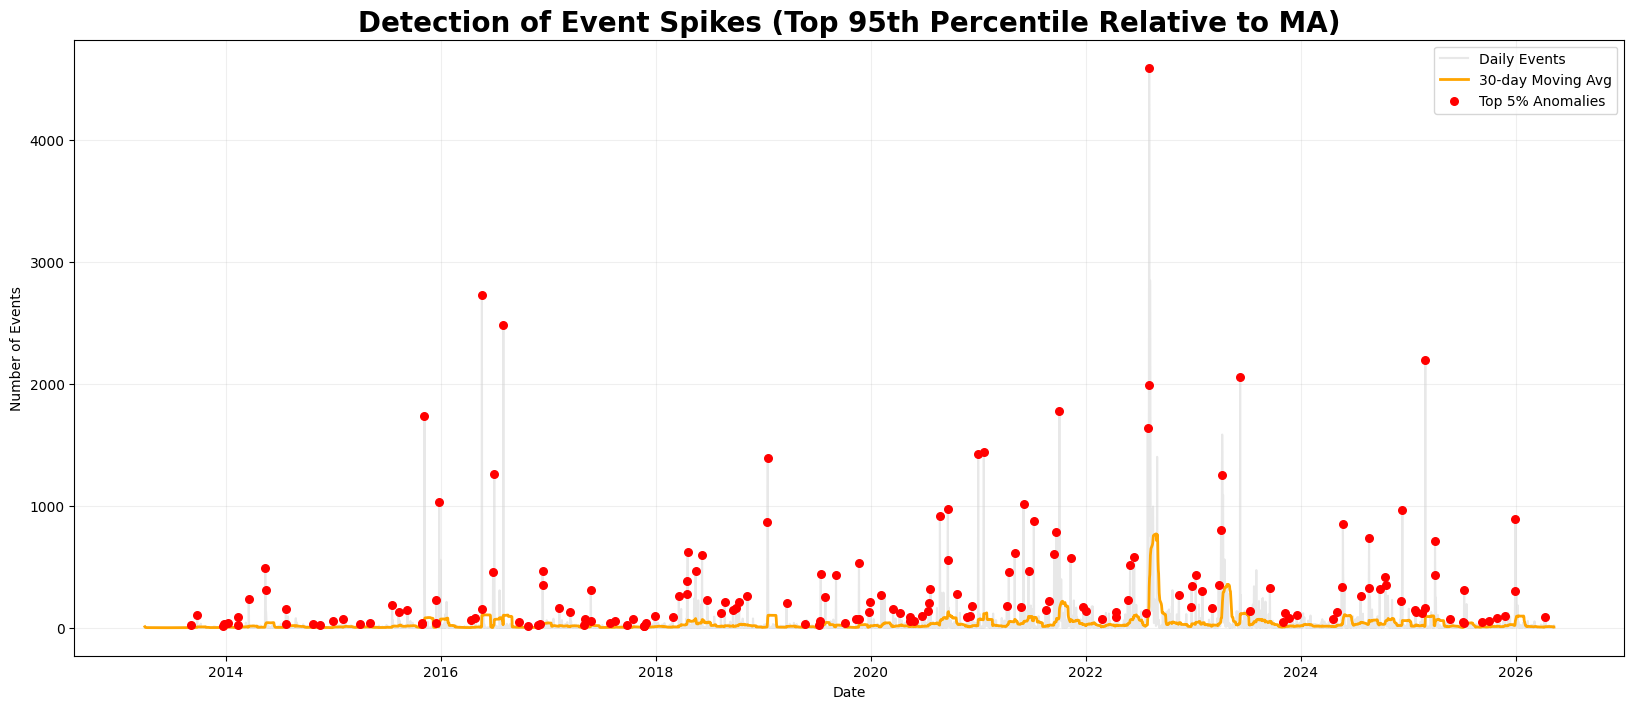

In [16]:
plt.figure(figsize=(20, 8))

# 전체 빈도수 그래프
plt.plot(ts_data.index, ts_data['event_count'], label='Daily Events', color='lightgray', alpha=0.5)
plt.plot(ts_data.index, ts_data['MA30'], label='30-day Moving Avg', color='orange', linewidth=2)

# 급증일(Anomalies) 표시
plt.scatter(anomalies.index, anomalies['event_count'], color='red', s=30, label='Top 5% Anomalies', zorder=3)

plt.title('Detection of Event Spikes (Top 95th Percentile Relative to MA)', fontsize=20, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [17]:
# 1. 기초 통계량 확인
stats = ts_data['event_count'].describe()
print("--- 기사량 기초 통계 ---")
print(stats)

# 2. 최소 기사량 기준(Min Count) 설정
min_event_threshold = stats['mean'] # 혹은 stats['50%'] (중위값)

print(f"\n추천 최소 기사량 기준: {min_event_threshold:.2f} (전체 평균 적용)")

--- 기사량 기초 통계 ---
count        4788.0
mean      33.052005
std      158.169976
min             0.0
25%             0.0
50%             1.0
75%            15.0
max          4595.0
Name: event_count, dtype: Float64

추천 최소 기사량 기준: 33.05 (전체 평균 적용)


--- 연도별 일일 평균 기사량 (Baseline) ---


,Year,Yearly_Avg_Count
0,2013,1.64
1,2014,9.024658
2,2015,18.772603
3,2016,29.592896
4,2017,8.087671
5,2018,21.561644
6,2019,20.616438
7,2020,32.743169
8,2021,55.473973
9,2022,100.613699


C:\Users\Jua\AppData\Local\Temp\ipykernel_14524\2493978214.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_averages, x='Year', y='Yearly_Avg_Count', palette='Blues_d')


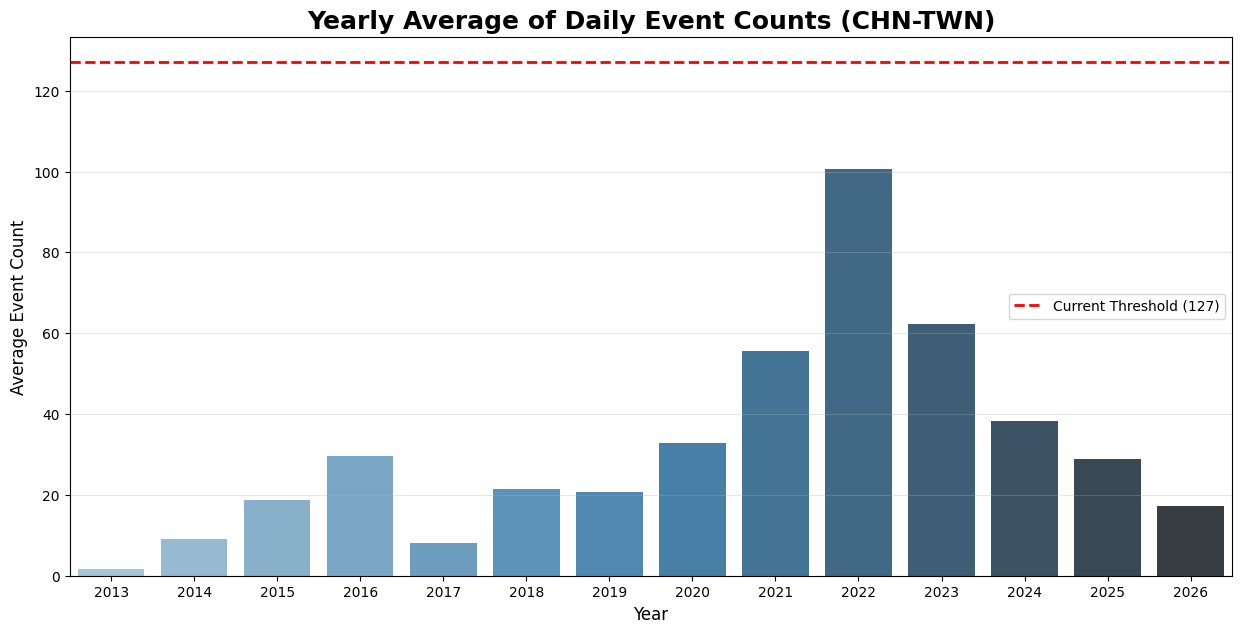

In [18]:
# 1. 연도별 평균 기사량 계산
yearly_averages = ts_data['event_count'].groupby(ts_data.index.year).mean().reset_index()
yearly_averages.columns = ['Year', 'Yearly_Avg_Count']

# 2. 결과 출력
print("--- 연도별 일일 평균 기사량 (Baseline) ---")
display(yearly_averages)

# 3. 시각화 (막대 그래프 + 127건 라인)
plt.figure(figsize=(15, 7))
sns.barplot(data=yearly_averages, x='Year', y='Yearly_Avg_Count', palette='Blues_d')

# 우리가 설정했던 기준선(127)을 그려서 비교
plt.axhline(y=127, color='red', linestyle='--', linewidth=2, label='Current Threshold (127)')

plt.title('Yearly Average of Daily Event Counts (CHN-TWN)', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Event Count', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [19]:
# 평균과 표준편차를 동시에 확인
yearly_stats = ts_data['event_count'].groupby(ts_data.index.year).agg(['mean', 'std', 'max'])
display(yearly_stats)

,mean,std,max
2013,1.64,7.547746,103
2014,9.024658,36.468064,489
2015,18.772603,112.99244,1738
2016,29.592896,207.474655,2729
2017,8.087671,23.555825,313
2018,21.561644,67.871846,623
2019,20.616438,102.476777,1391
2020,32.743169,114.534051,1429
2021,55.473973,164.770762,1775
2022,100.613699,373.322977,4595


In [20]:
import geopandas as gpd
print(gpd.__version__)

1.1.3


GeoPandas 1.0 업데이트로 내장 데이터셋이 삭제된 이슈 확인. geodatasets 패키지로 대응하려 했으나, 환경마다 데이터셋 키(Key)값이 달라지는 가변성 문제 인지. 그래서 시스템의 안정성을 위해 Natural Earth의 원본 GeoJSON 소스를 직접 참조하는 방식으로 파이프라인을 구축하여 의존성 해결

In [21]:
from shapely.geometry import Point

# 1. Natural Earth의 국가 경계 데이터를 URL에서 직접 로드 (110m 저해상도)
# 이 링크는 가장 표준적으로 쓰이는 전 세계 국가 경계 데이터입니다.
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

# 2. 대상 국가 필터링 (데이터셋마다 이름이 다를 수 있으니 확인 필요)
# 보통 'NAME' 또는 'name' 컬럼을 사용합니다.
target_country = world[world['NAME'].isin(['Taiwan', 'China'])]

# 버퍼 적용 (육지 경계에서 약 20km 확장)
target_country_buffered = target_country.buffer(0.2)

def verify_pip(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return "Fail (Missing)"
    
    # GDELT는 (경도, 위도) 순서로 Point를 생성
    point = Point(lon, lat)
    
    # 해당 좌표가 폴리곤(국가 경계) 내에 포함되는지 확인
    is_inside = target_country.contains(point).any()
    
    return "Pass" if is_inside else "Fail (Out of Bounds)"

# 3. 1단계 전수조사 적용
df['Geo_Verification_Stage1'] = df.apply(lambda x: verify_pip(x['ActionGeo_Lat'], x['ActionGeo_Long']), axis=1)

# 결과 확인
print(df['Geo_Verification_Stage1'].value_counts())

C:\Users\Jua\AppData\Local\Temp\ipykernel_14524\2469577625.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_country_buffered = target_country.buffer(0.2)


Geo_Verification_Stage1
Pass                    9775
Fail (Out of Bounds)    2125
Name: count, dtype: int64


C:\Users\Jua\AppData\Local\Temp\ipykernel_14524\3314937819.py:56: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  buffer_patch = mpatches.Patch(color='green', alpha=0.15, edgecolor='green', linestyle='--', label='Buffer Zone (~20km)')


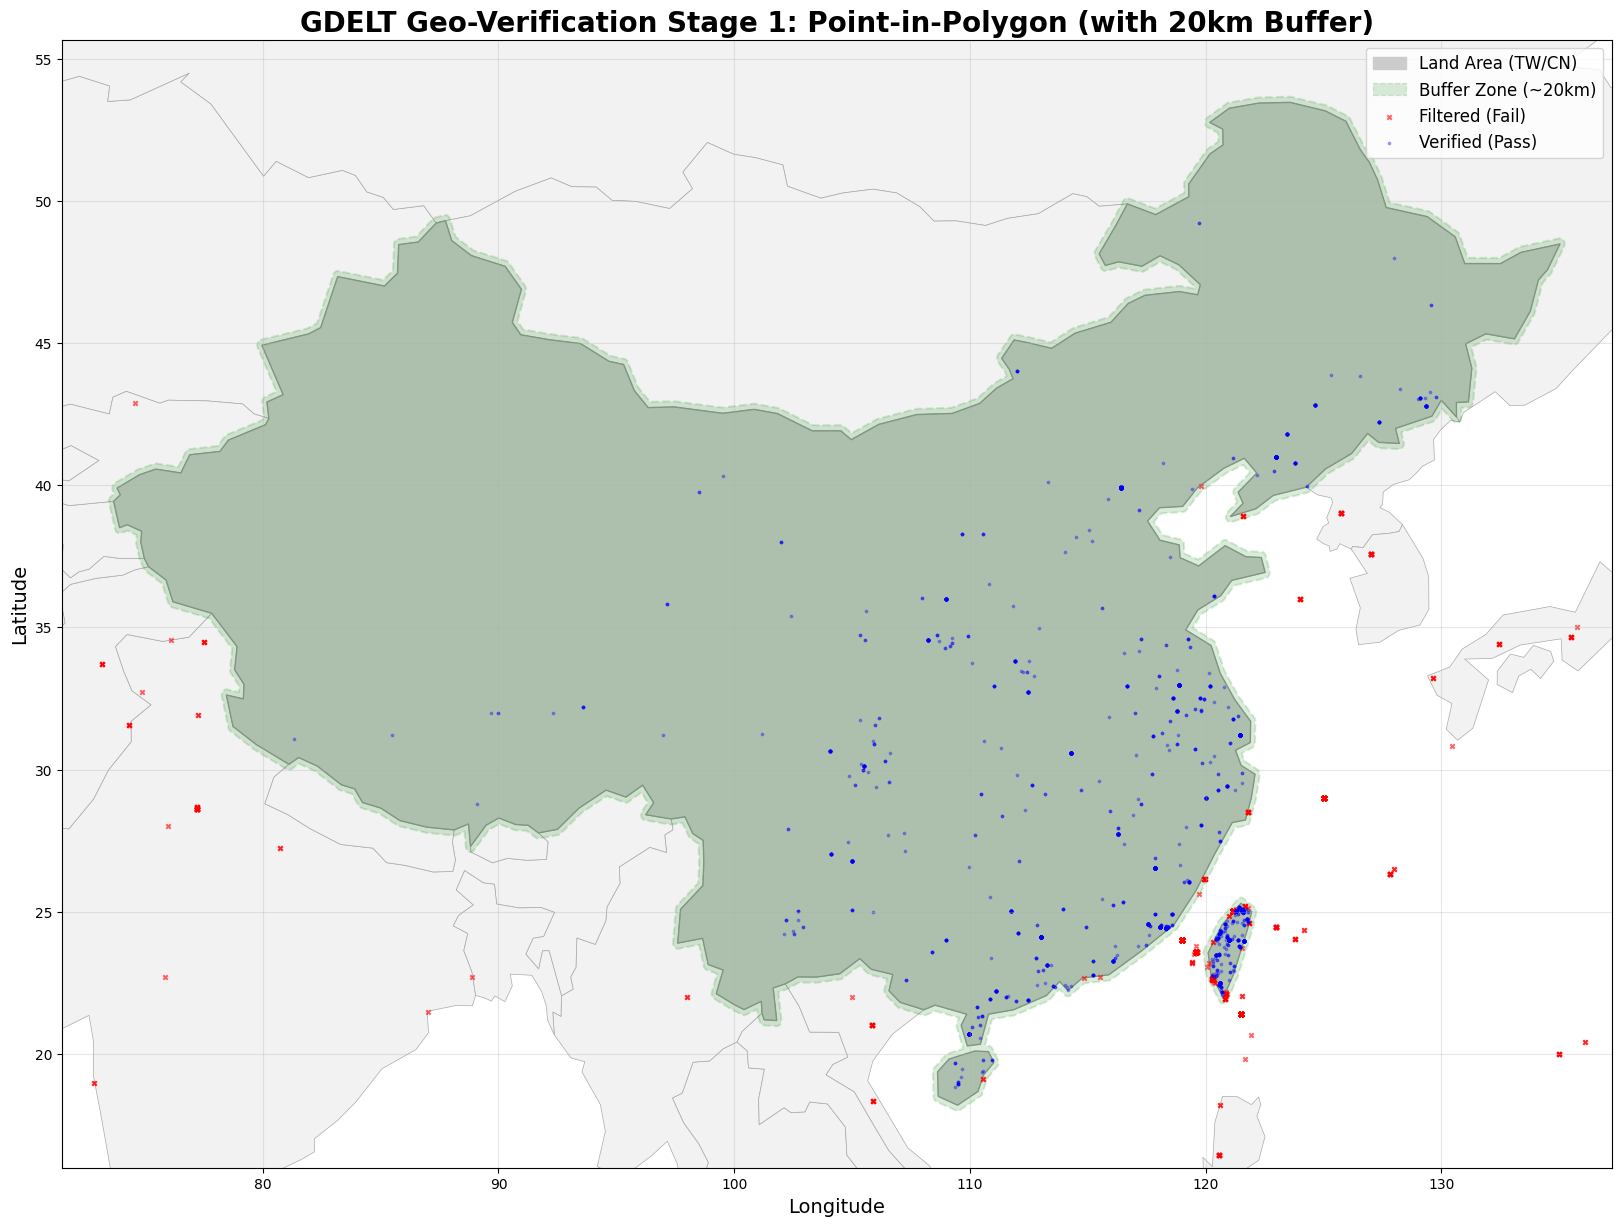

In [22]:
import matplotlib.patches as mpatches # 범례 설정을 위해 필요

# --- 데이터 준비 단계 ---

# 1. Pandas DataFrame을 GeoDataFrame으로 변환
# GDELT는 (경도, 위도) 순서로 Point를 생성
df_points_geo = df.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long']).copy() # 좌표 없는 데이터 제거
geometry = [Point(xy) for xy in zip(df_points_geo['ActionGeo_Long'], df_points_geo['ActionGeo_Lat'])]
gdf_points = gpd.GeoDataFrame(df_points_geo, geometry=geometry, crs="EPSG:4326")

# 2. 시각화를 위해 Pass/Fail 데이터 분리
gdf_pass = gdf_points[gdf_points['Geo_Verification_Stage1'] == 'Pass']
gdf_fail = gdf_points[gdf_points['Geo_Verification_Stage1'] == 'Fail (Out of Bounds)']


# --- 시각화 실행 단계 ---

# 1. 플롯 및 배경 지도(Natural Earth) 설정
fig, ax = plt.subplots(figsize=(20, 15))

# 배경 지도 로드 (세계 지도에서 대상 지역 근처만 사용)
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)
world.plot(ax=ax, color='#f2f2f2', edgecolor='#aaaaaa', linewidth=0.5) # 연한 회색 배경

# 2. 대상 국가 및 버퍼 영역 그리기
target_country.plot(ax=ax, color='#cccccc', edgecolor='#999999', linewidth=1.0) # 육지
gpd.GeoDataFrame(geometry=target_country_buffered, crs="EPSG:4326").plot(
    ax=ax, color='green', alpha=0.15, edgecolor='green', linestyle='--', linewidth=1.5
) # 버퍼 영역 (연한 초록색)

# 3. GDELT 좌표 그리기 (Fail부터 그리기 - Pass가 위로 오게 하기 위해)
# Fail: 빨간색, Pass: 파란색
gdf_fail.plot(ax=ax, color='red', markersize=10, alpha=0.6, marker='x', label='Filtered (Fail)')
gdf_pass.plot(ax=ax, color='blue', markersize=3, alpha=0.3, label='Verified (Pass)')


# 4. 지도 보기 영역 조정 (대만/중국 해안가 중심으로 줌인)
# 버퍼 폴리곤의 전체 경계를 기준으로 줌 레벨 설정
minx, miny, maxx, maxy = target_country_buffered.total_bounds
# 여백 확보를 위한 패딩 추가
padding = 2.0
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)


# 5. Aesthetics (제목, 범례 등)
plt.title('GDELT Geo-Verification Stage 1: Point-in-Polygon (with 20km Buffer)', fontsize=20, fontweight='bold')
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.grid(True, alpha=0.3)

# GeoPandas 범례는 복잡하므로 matplotlib으로 직접 범례 설정
handles, _ = ax.get_legend_handles_labels()
land_patch = mpatches.Patch(color='#cccccc', label='Land Area (TW/CN)')
buffer_patch = mpatches.Patch(color='green', alpha=0.15, edgecolor='green', linestyle='--', label='Buffer Zone (~20km)')
ax.legend(handles=[land_patch, buffer_patch, *handles], loc='upper right', fontsize=12)

plt.show()

In [23]:
# 가중치 스코어링 함수 정의
def calculate_event_score(row):
    # Volume Score (NumMentions에 로그 적용하여 편차 완화)
    volume_score = np.log1p(row['NumMentions']) 
    
    # Impact Score (GoldsteinScale의 절대값)
    impact_score = abs(row['GoldsteinScale'])
    
    # AvgTone Score
    # 논조가 마이너스(부정적)일 때만 리스크 점수로 환산(예: -5.4면 5.4점)
    # 논조가 플러스(긍정적/평화적)인 경우 리스크는 0점으로 처리
    if pd.isna(row['AvgTone']):
        tone_score = 0
    else:
        tone_score = abs(min(0, row['AvgTone']))

    # 최종 점수 계산 (가중치: Volume 5 : Impact 2 : Risk 3)
    final_score = (volume_score * 5) + (impact_score * 3) + (tone_score * 2)
    return final_score

# 스코어 계산 및 적용
df['Importance_Score'] = df.apply(calculate_event_score, axis=1)

# 결과 확인
print(f"데이터 로드 완료: 총 {len(df)}건")
top_events = df.sort_values(by='Importance_Score', ascending=False).head(10)
display(top_events[['SQLDATE', 'EventCode', 'NumMentions', 'GoldsteinScale', 'Importance_Score']])


데이터 로드 완료: 총 11900건


,SQLDATE,EventCode,NumMentions,GoldsteinScale,Importance_Score
3687,2026-03-29,190,8,-10.0,77.349759
5256,2022-08-07,190,1420,-10.0,74.619537
10994,2021-10-03,192,840,-9.5,72.739369
6952,2025-02-27,193,1026,-10.0,72.600125
2510,2024-08-19,190,264,-10.0,72.475948
4866,2022-05-24,190,10,-10.0,71.989476
3896,2026-04-23,193,10,-10.0,71.776710
7473,2022-08-04,194,700,-10.0,71.207770
7546,2022-08-04,194,536,-10.0,70.975918
5245,2022-08-07,190,583,-10.0,70.199527


In [24]:
# 가중치 스코어링 함수 정의
def calculate_event_score(row):
    # Volume Score (NumMentions에 로그 적용하여 편차 완화)
    volume_score = np.log1p(row['NumMentions']) 
    
    # Impact Score (GoldsteinScale의 절대값)
    impact_score = abs(row['GoldsteinScale'])
    
    # AvgTone Score
    # 논조가 마이너스(부정적)일 때만 리스크 점수로 환산(예: -5.4면 5.4점)
    # 논조가 플러스(긍정적/평화적)인 경우 리스크는 0점으로 처리
    if pd.isna(row['AvgTone']):
        tone_score = 0
    else:
        tone_score = abs(min(0, row['AvgTone']))

    # 최종 점수 계산
    final_score = (volume_score * 6) + (impact_score * 2) + (tone_score * 2)
    return final_score

# 스코어 계산 및 적용
df['Importance_Score'] = df.apply(calculate_event_score, axis=1)

# 결과 확인
print(f"데이터 로드 완료: 총 {len(df)}건")
top_events = df.sort_values(by='Importance_Score', ascending=False).head(10)
display(top_events[['SQLDATE', 'EventCode', 'NumMentions', 'GoldsteinScale', 'Importance_Score']])


데이터 로드 완료: 총 11900건


,SQLDATE,EventCode,NumMentions,GoldsteinScale,Importance_Score
5256,2022-08-07,190,1420,-10.0,71.878653
10994,2021-10-03,192,840,-9.5,69.973961
3687,2026-03-29,190,8,-10.0,69.546984
6952,2025-02-27,193,1026,-10.0,69.534522
2510,2024-08-19,190,264,-10.0,68.055678
7473,2022-08-04,194,700,-10.0,67.760278
7546,2022-08-04,194,536,-10.0,67.261916
5245,2022-08-07,190,583,-10.0,66.569428
767,2022-08-31,190,682,-10.0,66.441607
4738,2021-01-19,190,1406,-10.0,66.038869


In [25]:
# 가중치 스코어링 함수 정의
def calculate_event_score(row):
    # Volume Score (NumMentions에 로그 적용하여 편차 완화)
    volume_score = np.log1p(row['NumMentions']) 
    
    # Impact Score (GoldsteinScale의 절대값)
    impact_score = abs(row['GoldsteinScale'])
    
    # AvgTone Score
    # 논조가 마이너스(부정적)일 때만 리스크 점수로 환산(예: -5.4면 5.4점)
    # 논조가 플러스(긍정적/평화적)인 경우 리스크는 0점으로 처리
    if pd.isna(row['AvgTone']):
        tone_score = 0
    else:
        tone_score = abs(min(0, row['AvgTone']))

    # 최종 점수 계산
    final_score = (volume_score * 6) + (impact_score * 4) + (tone_score * 0)
    return final_score

# 스코어 계산 및 적용
df['Importance_Score'] = df.apply(calculate_event_score, axis=1)

# 결과 확인
print(f"데이터 로드 완료: 총 {len(df)}건")
top_events = df.sort_values(by='Importance_Score', ascending=False).head(10)
display(top_events[['SQLDATE', 'EventCode', 'NumMentions', 'GoldsteinScale', 'Importance_Score']])


데이터 로드 완료: 총 11900건


,SQLDATE,EventCode,NumMentions,GoldsteinScale,Importance_Score
5256,2022-08-07,190,1420,-10.0,83.554697
4738,2021-01-19,190,1406,-10.0,83.495290
6952,2025-02-27,193,1026,-10.0,81.606383
6746,2016-08-01,190,932,-10.0,81.030431
6753,2016-08-01,190,932,-10.0,81.030431
9352,2015-11-07,192,1052,-9.5,79.756391
5746,2021-06-03,193,751,-10.0,79.736418
7473,2022-08-04,194,700,-10.0,79.315047
7159,2024-08-20,194,690,-10.0,79.228839
767,2022-08-31,190,682,-10.0,79.158969


In [26]:
# 1. 먼저 최소 기사량 100건 이상인 데이터만 따로 추출 (점수 변별력 확보를 위해)
valid_df = df[df['NumMentions'] >= 100].copy()

if len(valid_df) > 0:
    # 2. 유효한 데이터 내에서 지표별 최대값 다시 계산
    # (극단적인 한두 건 때문에 점수가 뭉치지 않도록 실제 데이터의 범위를 사용)
    current_max_vol = np.log1p(valid_df['NumMentions']).max()
    current_max_imp = 10  # Goldstein은 10 고정
    
    # Risk 지표 생성 및 최대값 계산
    valid_df['raw_risk'] = valid_df['AvgTone'].apply(lambda x: abs(min(0, x)) if pd.notna(x) else 0) * np.sqrt(valid_df['NumMentions'])
    current_max_risk = valid_df['raw_risk'].max()

    def calculate_event_score(row):
        # 각 지표 정규화 (현재 유효 데이터 중 최대값 대비 비율)
        vol_norm = np.log1p(row['NumMentions']) / current_max_vol
        imp_norm = abs(row['GoldsteinScale']) / current_max_imp
        
        # Risk 정규화 (0 나누기 방지)
        risk_norm = row['raw_risk'] / current_max_risk if current_max_risk > 0 else 0
        
        # 100점 만점 가중치 합산 (합이 100이 되도록 설정)
        # 중요도에 따라 비율을 조정하세요
        final_score = (vol_norm * 60) + (imp_norm * 20) + (risk_norm * 20)
        return round(final_score, 2) # 소수점 둘째자리까지 표시해서 변별력 강화

    # 3. 점수 적용
    valid_df['Importance_Score'] = valid_df.apply(calculate_event_score, axis=1)

    # 4. 결과 확인
    top_events = valid_df.sort_values(by='Importance_Score', ascending=False).head(10)
    display(top_events[['SQLDATE', 'EventCode', 'NumMentions', 'GoldsteinScale', 'AvgTone', 'Importance_Score']])
else:
    print("조건을 만족하는(기사량 100건 이상) 데이터가 없습니다.")

,SQLDATE,EventCode,NumMentions,GoldsteinScale,AvgTone,Importance_Score
5256,2022-08-07,190,1420,-10.0,-4.161978,99.73
10994,2021-10-03,192,840,-9.5,-5.283206,93.94
6952,2025-02-27,193,1026,-10.0,-3.964070,93.25
516,2022-08-08,150,1242,-7.2,-4.208492,91.94
7473,2022-08-04,194,700,-10.0,-4.222615,88.16
10910,2020-12-31,151,1190,-7.2,-3.208156,86.79
767,2022-08-31,190,682,-10.0,-3.641319,85.83
7546,2022-08-04,194,536,-10.0,-4.772964,85.81
4738,2021-01-19,190,1406,-10.0,-1.271789,85.73
5245,2022-08-07,190,583,-10.0,-4.175011,85.27


In [27]:
# 1. '날짜'와 '사건코드'가 모두 동일한 그룹 확인
duplicate_check = df.groupby(['SQLDATE', 'EventCode']).size().reset_index(name='count')

# 2. 중복이 발생한 그룹(사건 발생 횟수 > 1) 추출
duplicates_only = duplicate_check[duplicate_check['count'] > 1]

# 3. 통계 요약
total_groups = len(duplicate_check)
duplicate_groups = len(duplicates_only)
max_duplicate_count = duplicate_check['count'].max()

print(f"--- 날짜 & 코드 중복 분석 결과 ---")
print(f"1. 전체 '날짜+코드' 유니크 조합: {total_groups}건")
print(f"2. 중복이 발생한 조합 수: {duplicate_groups}건 (전체의 {duplicate_groups/total_groups*100:.2f}%)")
print(f"3. 특정 날짜/코드 최대 중복 횟수: {max_duplicate_count}번")

# 4. 어떤 날짜/코드가 가장 많이 겹치는지 상위 10개 확인
display(duplicates_only.sort_values(by='count', ascending=False).head(10))

--- 날짜 & 코드 중복 분석 결과 ---
1. 전체 '날짜+코드' 유니크 조합: 4063건
2. 중복이 발생한 조합 수: 2487건 (전체의 61.21%)
3. 특정 날짜/코드 최대 중복 횟수: 57번


,SQLDATE,EventCode,count
2415,2022-08-04,150,57
2422,2022-08-04,194,52
475,2016-07-01,194,41
2805,2023-04-10,190,40
2430,2022-08-05,194,40
2456,2022-08-09,194,37
2795,2023-04-09,150,36
2788,2023-04-08,150,35
3527,2024-10-14,150,35
2802,2023-04-10,150,35


In [28]:
# 1. 2022년 8월 4일 데이터만 필터링
aug_4_df = df[df['SQLDATE'] == '2022-08-04'].copy()

# 2. 언급량(NumMentions) 기준 내림차순 정렬
# (중요도 점수가 계산되어 있다면 Importance_Score로 정렬해도 좋습니다)
aug_4_sorted = aug_4_df.sort_values(by='NumMentions', ascending=False)

print(f"--- 2022년 8월 4일 상세 사건 분석 (총 {len(aug_4_sorted)}건 포착) ---")

# 주요 컬럼들만 선택해서 출력 (ActionGeo_Type 등으로 위치 중복 확인 가능)
display(aug_4_sorted[['SQLDATE', 'EventCode', 'NumMentions', 'AvgTone', 'GoldsteinScale', 'ActionGeo_Lat', 'ActionGeo_Long']].head(20))

--- 2022년 8월 4일 상세 사건 분석 (총 153건 포착) ---


,SQLDATE,EventCode,NumMentions,AvgTone,GoldsteinScale,ActionGeo_Lat,ActionGeo_Long
7473,2022-08-04,194,700,-4.222615,-10.0,28.7925,117.2620
7546,2022-08-04,194,536,-4.772964,-10.0,24.0000,119.0000
7560,2022-08-04,150,378,-2.070194,-7.2,39.9289,116.3880
7484,2022-08-04,194,300,-4.222615,-10.0,32.9500,116.6420
7578,2022-08-04,194,281,-3.074827,-10.0,25.0478,121.5320
7562,2022-08-04,194,265,-3.880930,-10.0,39.9289,116.3880
7492,2022-08-04,194,159,-3.681634,-10.0,39.9289,116.3880
7561,2022-08-04,150,130,-2.139968,-7.2,39.9289,116.3880
7622,2022-08-04,194,101,-2.073469,-10.0,38.8951,-77.0364
7525,2022-08-04,150,96,-2.530253,-7.2,24.1098,113.0050


In [29]:
# 날짜별로 그룹화하여 행 개수(size) 계산
daily_event_counts = df.groupby('SQLDATE').size().reset_index(name='event_row_count')

# 행 개수가 많은 순서대로 상위 10개 추출
top_10_busy_days = daily_event_counts.sort_values(by='event_row_count', ascending=False).head(10)

print("--- 🚨 사건 발생 빈도(데이터 행 수) 상위 10일 ---")
display(top_10_busy_days)

# 참고: 기사 언급량 합계와 비교해보기 위해 같이 출력
daily_summary = df.groupby('SQLDATE').agg(
    row_count=('SQLDATE', 'size'),
    total_mentions=('NumMentions', 'sum')
).sort_values(by='row_count', ascending=False).head(10)

print("\n--- 💡 사건 수 vs 기사 언급량 비교 ---")
display(daily_summary)

--- 🚨 사건 발생 빈도(데이터 행 수) 상위 10일 ---


,SQLDATE,event_row_count
1519,2022-08-04,153
1695,2023-04-10,114
1520,2022-08-05,93
1524,2022-08-09,87
1694,2023-04-09,83
1693,2023-04-08,71
1518,2022-08-03,71
1696,2023-04-11,68
1521,2022-08-06,62
1522,2022-08-07,58



--- 💡 사건 수 vs 기사 언급량 비교 ---


,row_count,total_mentions
SQLDATE,,
2022-08-04,153,4595
2023-04-10,114,1398
2022-08-05,93,2283
2022-08-09,87,751
2023-04-09,83,1585
2023-04-08,71,1256
2022-08-03,71,1988
2023-04-11,68,868
2022-08-06,62,896
